# Лабораторная 4 — нейронная сеть для бинарной классификации

**Содержание:**
1. Архитектуры моделей (однослойная сеть и перцептрон с одним скрытым слоем BReLU);
2. Семейство оптимизаторов: SGD, Momentum, Nesterov, AdaGrad, RMSProp, **Adam = Momentum + RMSProp**, NAdam-подобный;
3. Эксперименты на двух наборах данных (`make_moons`, `make_classification`), `random_state = 467715`;
4. Перебор гиперпараметров, графики обучения, метрики на тестовой выборке.

Код реализации находится в папке `src/` (`activations.py`, `losses.py`, `optimizer.py`, `model.py`, `utils.py`).


In [1]:
import sys, os, warnings
sys.path.append('src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.preprocessing import StandardScaler

from utils import seed_everything, split_train_val_test, classification_report
from activations import Sigmoid, BReLU
from losses import BinaryCrossEntropy
from optimizer import SGD
from model import SingleLayerNet, MLP1Hidden

SEED = 467715
seed_everything(SEED)
plt.rcParams.update({'figure.dpi': 90, 'figure.figsize': (8, 4.5)})
os.makedirs('figures', exist_ok=True)
print('зерно =', SEED)


зерно = 467715


## 1. Генерация наборов данных

In [2]:
X_moons, y_moons = make_moons(n_samples=400, noise=0.15, random_state=SEED)
X_clf, y_clf = make_classification(
    n_samples=200, n_features=5, n_redundant=2, random_state=SEED,
    n_informative=2, n_clusters_per_class=2, n_classes=2,
)

print('moons:           X', X_moons.shape, 'баланс классов', np.bincount(y_moons))
print('classification:  X', X_clf.shape,   'баланс классов', np.bincount(y_clf))


moons:           X (400, 2) баланс классов [200 200]
classification:  X (200, 5) баланс классов [100 100]


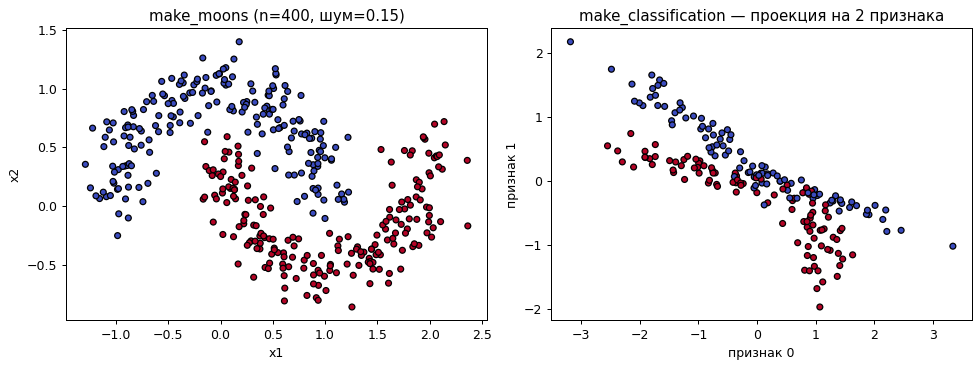

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolor='k', s=22)
axes[0].set_title('make_moons (n=400, шум=0.15)')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

# проекция make_classification на два первых признака
axes[1].scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='coolwarm', edgecolor='k', s=22)
axes[1].set_title('make_classification — проекция на 2 признака')
axes[1].set_xlabel('признак 0'); axes[1].set_ylabel('признак 1')
plt.tight_layout(); plt.savefig('figures/01_datasets.png', dpi=120); plt.show()


## 2. Подготовка данных (60/20/20 со стратификацией + нормировка)

In [4]:
def prepare(X, y, seed=SEED):
    sp = split_train_val_test(X, y, random_state=seed)
    sc = StandardScaler().fit(sp.X_train)
    return (
        sc.transform(sp.X_train), sp.y_train,
        sc.transform(sp.X_val),   sp.y_val,
        sc.transform(sp.X_test),  sp.y_test,
    )

Xm_tr, ym_tr, Xm_va, ym_va, Xm_te, ym_te = prepare(X_moons, y_moons)
Xc_tr, yc_tr, Xc_va, yc_va, Xc_te, yc_te = prepare(X_clf, y_clf)
print('moons:         ', Xm_tr.shape, Xm_va.shape, Xm_te.shape)
print('classification:', Xc_tr.shape, Xc_va.shape, Xc_te.shape)


moons:          (240, 2) (80, 2) (80, 2)
classification: (120, 5) (40, 5) (40, 5)


## 3. Каталог оптимизаторов

`SGD` — единый класс с переключателями `momentum ∈ {none, classic, nesterov}` и `adaptive ∈ {none, adagrad, rmsprop}`.
Каждая «именованная» комбинация соответствует своему методу:

| Название     | `momentum` | `adaptive` |
|--------------|------------|------------|
| SGD          | none       | none       |
| Momentum     | classic    | none       |
| Nesterov     | nesterov   | none       |
| AdaGrad      | none       | adagrad    |
| RMSProp      | none       | rmsprop    |
| **Adam**     | classic    | rmsprop    |
| NAdam-подобн.| nesterov   | rmsprop    |


In [5]:
OPT_PRESETS = [
    dict(name='SGD',       momentum='none',     adaptive='none'),
    dict(name='Momentum',  momentum='classic',  adaptive='none'),
    dict(name='Nesterov',  momentum='nesterov', adaptive='none'),
    dict(name='AdaGrad',   momentum='none',     adaptive='adagrad'),
    dict(name='RMSProp',   momentum='none',     adaptive='rmsprop'),
    dict(name='Adam',      momentum='classic',  adaptive='rmsprop'),
    dict(name='NAdam',     momentum='nesterov', adaptive='rmsprop'),
]

# сетка шагов обучения зависит от семейства — адаптивные методы любят шаг поменьше
LR_GRID = {
    'SGD':      [0.05, 0.1, 0.5],
    'Momentum': [0.01, 0.05, 0.1],
    'Nesterov': [0.01, 0.05, 0.1],
    'AdaGrad':  [0.1, 0.5, 1.0],
    'RMSProp':  [0.005, 0.01, 0.05],
    'Adam':     [0.005, 0.01, 0.05],
    'NAdam':    [0.005, 0.01, 0.05],
}
BATCH_GRID = [16, 32, 64]
EPOCHS = 400
PATIENCE = 60


## 4. Перебор гиперпараметров (по минимуму валидационной потери)

In [6]:
def search(model_cls, model_kwargs, Xtr, ytr, Xva, yva, epochs=EPOCHS, patience=PATIENCE):
    rows = []
    best = None
    for preset in OPT_PRESETS:
        for lr in LR_GRID[preset['name']]:
            for bs in BATCH_GRID:
                seed_everything(SEED)
                model = model_cls(**model_kwargs, seed=SEED)
                opt = SGD(lr=lr, batch_size=bs,
                          momentum=preset['momentum'], adaptive=preset['adaptive'])
                h = model.fit(Xtr, ytr, Xva, yva,
                              optimizer=opt, epochs=epochs,
                              early_stopping_patience=patience, seed=SEED)
                vloss = float(min(h.val_loss))
                vacc  = float(max(h.val_acc))
                rows.append(dict(opt=preset['name'], lr=lr, batch=bs,
                                 val_loss=vloss, val_acc=vacc,
                                 epochs_run=len(h.train_loss)))
                if (best is None) or (vloss < best['val_loss']):
                    best = dict(opt=preset['name'], lr=lr, batch=bs,
                                val_loss=vloss, val_acc=vacc,
                                model=model, history=h, preset=preset)
    return pd.DataFrame(rows).sort_values('val_loss').reset_index(drop=True), best


### 4.1 Однослойная сеть на `moons`

In [7]:
slp_moons_grid, slp_moons_best = search(
    SingleLayerNet, dict(n_features=Xm_tr.shape[1]),
    Xm_tr, ym_tr, Xm_va, ym_va,
)
print('Лучшие 5 конфигураций:')
print(slp_moons_grid.head(5).to_string(index=False))
print('\nЛучшая:', slp_moons_best['opt'], 'шаг=', slp_moons_best['lr'], 'пакет=', slp_moons_best['batch'],
      'val_loss=', round(slp_moons_best['val_loss'], 4),
      'val_acc=',  round(slp_moons_best['val_acc'], 4))


Лучшие 5 конфигураций:
    opt   lr  batch  val_loss  val_acc  epochs_run
RMSProp 0.05     32  0.346951   0.8250          63
   Adam 0.05     64  0.349385   0.8250          66
RMSProp 0.05     16  0.349438   0.8250          62
  NAdam 0.05     64  0.349536   0.8375          66
AdaGrad 0.10     32  0.349872   0.8250          65

Лучшая: RMSProp шаг= 0.05 пакет= 32 val_loss= 0.347 val_acc= 0.825


### 4.2 Перцептрон с одним скрытым слоем на `moons` (с перебором размера скрытого слоя)

In [8]:
def search_mlp(Xtr, ytr, Xva, yva, hidden_sizes=(8, 16, 32)):
    rows, best = [], None
    for H in hidden_sizes:
        df, b = search(MLP1Hidden, dict(n_features=Xtr.shape[1], hidden_size=H, brelu_bound=1.0),
                       Xtr, ytr, Xva, yva)
        df['hidden'] = H
        rows.append(df)
        if (best is None) or (b['val_loss'] < best['val_loss']):
            best = {**b, 'hidden': H}
    return pd.concat(rows, ignore_index=True).sort_values('val_loss').reset_index(drop=True), best

mlp_moons_grid, mlp_moons_best = search_mlp(Xm_tr, ym_tr, Xm_va, ym_va)
print('Лучшие 5 конфигураций:')
print(mlp_moons_grid.head(5).to_string(index=False))
print('\nЛучшая:', mlp_moons_best['opt'], 'скрытых=', mlp_moons_best['hidden'],
      'шаг=', mlp_moons_best['lr'], 'пакет=', mlp_moons_best['batch'],
      'val_loss=', round(mlp_moons_best['val_loss'], 4),
      'val_acc=',  round(mlp_moons_best['val_acc'], 4))


Лучшие 5 конфигураций:
    opt   lr  batch  val_loss  val_acc  epochs_run  hidden
RMSProp 0.05     16  0.010378      1.0         366       8
RMSProp 0.05     32  0.014488      1.0         197      32
  NAdam 0.05     32  0.015673      1.0         400       8
  NAdam 0.05     16  0.015914      1.0         360      32
RMSProp 0.05     16  0.017267      1.0         134      32

Лучшая: RMSProp скрытых= 8 шаг= 0.05 пакет= 16 val_loss= 0.0104 val_acc= 1.0


### 4.3 Однослойная сеть на `classification`

In [9]:
slp_clf_grid, slp_clf_best = search(
    SingleLayerNet, dict(n_features=Xc_tr.shape[1]),
    Xc_tr, yc_tr, Xc_va, yc_va,
)
print(slp_clf_grid.head(5).to_string(index=False))
print('\nЛучшая:', slp_clf_best['opt'], 'шаг=', slp_clf_best['lr'], 'пакет=', slp_clf_best['batch'],
      'val_loss=', round(slp_clf_best['val_loss'], 4),
      'val_acc=',  round(slp_clf_best['val_acc'], 4))


    opt   lr  batch  val_loss  val_acc  epochs_run
AdaGrad 1.00     16  0.175994     0.95          67
AdaGrad 1.00     64  0.179405     0.95          68
AdaGrad 1.00     32  0.179536     0.95          67
RMSProp 0.05     16  0.181331     0.95         151
AdaGrad 0.50     16  0.183077     0.95          67

Лучшая: AdaGrad шаг= 1.0 пакет= 16 val_loss= 0.176 val_acc= 0.95


### 4.4 Перцептрон с одним скрытым слоем на `classification`

In [10]:
mlp_clf_grid, mlp_clf_best = search_mlp(Xc_tr, yc_tr, Xc_va, yc_va)
print(mlp_clf_grid.head(5).to_string(index=False))
print('\nЛучшая:', mlp_clf_best['opt'], 'скрытых=', mlp_clf_best['hidden'],
      'шаг=', mlp_clf_best['lr'], 'пакет=', mlp_clf_best['batch'],
      'val_loss=', round(mlp_clf_best['val_loss'], 4),
      'val_acc=',  round(mlp_clf_best['val_acc'], 4))


    opt   lr  batch  val_loss  val_acc  epochs_run  hidden
RMSProp 0.05     16  0.087020    0.950         144      16
RMSProp 0.01     16  0.093723    0.975         400      16
AdaGrad 1.00     16  0.094904    0.975         142      32
   Adam 0.05     64  0.103659    0.975         239      16
RMSProp 0.01     32  0.108281    0.975         400      16

Лучшая: RMSProp скрытых= 16 шаг= 0.05 пакет= 16 val_loss= 0.087 val_acc= 0.95


## 5. Сравнение кривых обучения для разных оптимизаторов (перцептрон на `moons`)

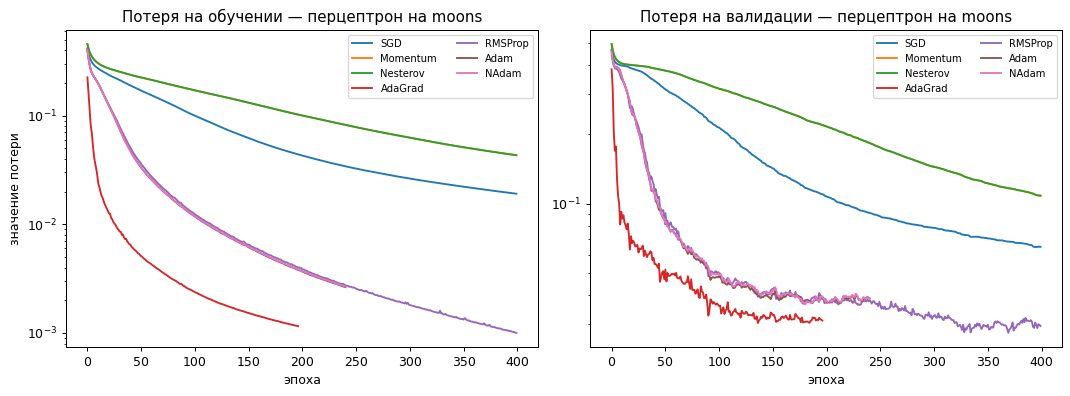

In [11]:
def train_with_preset(model_cls, model_kwargs, preset, lr, bs, Xtr, ytr, Xva, yva,
                       epochs=EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = model_cls(**model_kwargs, seed=SEED)
    opt = SGD(lr=lr, batch_size=bs, momentum=preset['momentum'], adaptive=preset['adaptive'])
    h = model.fit(Xtr, ytr, Xva, yva, optimizer=opt,
                  epochs=epochs, early_stopping_patience=patience, seed=SEED)
    return model, h, opt

H_DEMO = 16
LR_DEMO = {'SGD': 0.1, 'Momentum': 0.05, 'Nesterov': 0.05,
           'AdaGrad': 0.5, 'RMSProp': 0.01, 'Adam': 0.01, 'NAdam': 0.01}
BS_DEMO = 32

curves = {}
for preset in OPT_PRESETS:
    name = preset['name']
    _, h, _ = train_with_preset(MLP1Hidden,
                                 dict(n_features=Xm_tr.shape[1], hidden_size=H_DEMO, brelu_bound=1.0),
                                 preset, LR_DEMO[name], BS_DEMO,
                                 Xm_tr, ym_tr, Xm_va, ym_va)
    curves[name] = h

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, h in curves.items():
    axes[0].plot(h.train_loss, label=name)
    axes[1].plot(h.val_loss,   label=name)
axes[0].set_title('Потеря на обучении — перцептрон на moons'); axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('значение потери')
axes[1].set_title('Потеря на валидации — перцептрон на moons'); axes[1].set_xlabel('эпоха')
axes[0].set_yscale('log'); axes[1].set_yscale('log')
axes[0].legend(fontsize=8, ncol=2); axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig('figures/02_optimizers_loss.png', dpi=120); plt.show()


## 6. Влияние размера мини-выборки (Adam, перцептрон на `moons`)

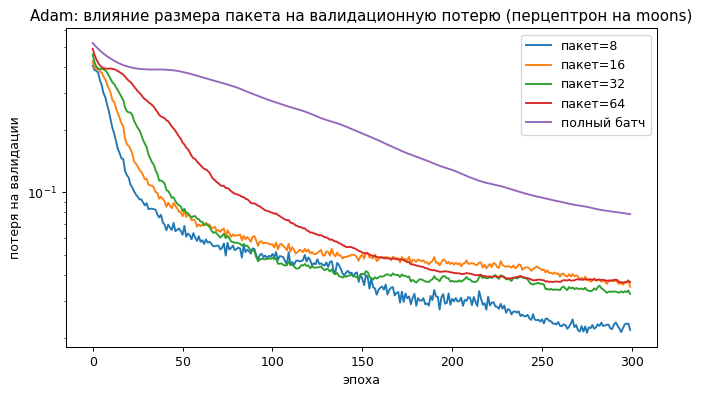

In [12]:
adam = next(p for p in OPT_PRESETS if p['name'] == 'Adam')
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for bs in [8, 16, 32, 64, len(Xm_tr)]:  # последнее значение — полный батч
    label = f'пакет={bs}' if bs < len(Xm_tr) else 'полный батч'
    _, h, _ = train_with_preset(MLP1Hidden,
                                 dict(n_features=Xm_tr.shape[1], hidden_size=H_DEMO, brelu_bound=1.0),
                                 adam, 0.01, bs, Xm_tr, ym_tr, Xm_va, ym_va, epochs=300, patience=80)
    ax.plot(h.val_loss, label=label)
ax.set_title('Adam: влияние размера пакета на валидационную потерю (перцептрон на moons)')
ax.set_xlabel('эпоха'); ax.set_ylabel('потеря на валидации'); ax.set_yscale('log'); ax.legend()
plt.tight_layout(); plt.savefig('figures/03_batch_size.png', dpi=120); plt.show()


## 7. Финальное обучение лучших моделей и метрики на тесте

In [13]:
def final_train_and_eval(model_cls, model_kwargs, best, Xtr, ytr, Xva, yva, Xte, yte,
                          epochs=EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model, h, opt = train_with_preset(model_cls, model_kwargs, best['preset'],
                                       best['lr'], best['batch'],
                                       Xtr, ytr, Xva, yva, epochs=epochs, patience=patience)
    report = classification_report(yte, model.predict(Xte))
    return model, h, opt, report

slp_m_model, slp_m_h, slp_m_opt, slp_m_rep = final_train_and_eval(
    SingleLayerNet, dict(n_features=Xm_tr.shape[1]),
    slp_moons_best, Xm_tr, ym_tr, Xm_va, ym_va, Xm_te, ym_te)
mlp_m_model, mlp_m_h, mlp_m_opt, mlp_m_rep = final_train_and_eval(
    MLP1Hidden, dict(n_features=Xm_tr.shape[1], hidden_size=mlp_moons_best['hidden'], brelu_bound=1.0),
    mlp_moons_best, Xm_tr, ym_tr, Xm_va, ym_va, Xm_te, ym_te)
slp_c_model, slp_c_h, slp_c_opt, slp_c_rep = final_train_and_eval(
    SingleLayerNet, dict(n_features=Xc_tr.shape[1]),
    slp_clf_best, Xc_tr, yc_tr, Xc_va, yc_va, Xc_te, yc_te)
mlp_c_model, mlp_c_h, mlp_c_opt, mlp_c_rep = final_train_and_eval(
    MLP1Hidden, dict(n_features=Xc_tr.shape[1], hidden_size=mlp_clf_best['hidden'], brelu_bound=1.0),
    mlp_clf_best, Xc_tr, yc_tr, Xc_va, yc_va, Xc_te, yc_te)

summary = pd.DataFrame([
    dict(dataset='moons',          model='SingleLayer', optimizer=slp_m_opt.name,
         lr=slp_moons_best['lr'], batch=slp_moons_best['batch'], hidden='-',
         **slp_m_rep),
    dict(dataset='moons',          model='MLP+BReLU',   optimizer=mlp_m_opt.name,
         lr=mlp_moons_best['lr'], batch=mlp_moons_best['batch'], hidden=mlp_moons_best['hidden'],
         **mlp_m_rep),
    dict(dataset='classification', model='SingleLayer', optimizer=slp_c_opt.name,
         lr=slp_clf_best['lr'], batch=slp_clf_best['batch'], hidden='-',
         **slp_c_rep),
    dict(dataset='classification', model='MLP+BReLU',   optimizer=mlp_c_opt.name,
         lr=mlp_clf_best['lr'], batch=mlp_clf_best['batch'], hidden=mlp_clf_best['hidden'],
         **mlp_c_rep),
])
print(summary.to_string(index=False))
summary.to_csv('figures/summary.csv', index=False)


       dataset       model optimizer   lr  batch hidden  accuracy  precision  recall       f1
         moons SingleLayer   RMSProp 0.05     32      -     0.875   0.840909   0.925 0.880952
         moons   MLP+BReLU   RMSProp 0.05     16      8     1.000   1.000000   1.000 1.000000
classification SingleLayer   AdaGrad 1.00     16      -     0.950   0.909091   1.000 0.952381
classification   MLP+BReLU   RMSProp 0.05     16     16     0.900   0.863636   0.950 0.904762


## 8. Разделяющая поверхность на двумерном `moons`

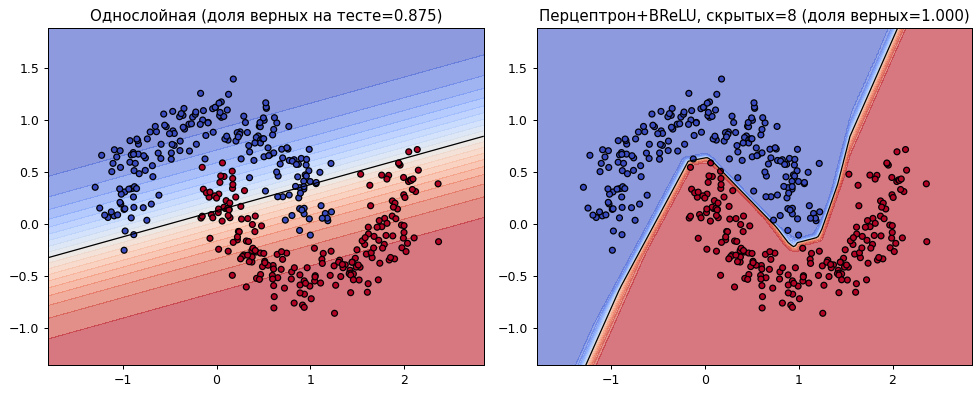

In [14]:
def plot_decision_boundary(model, X, y, ax, title, sc=None):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    if sc is not None:
        grid_s = sc.transform(grid)
    else:
        grid_s = grid
    Z = model.predict_proba(grid_s).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.0)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=22)
    ax.set_title(title)

# нормировщик для отрисовки в исходных координатах
sc_m = StandardScaler().fit(split_train_val_test(X_moons, y_moons, random_state=SEED).X_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision_boundary(slp_m_model, X_moons, y_moons, axes[0],
                       f'Однослойная (доля верных на тесте={slp_m_rep["accuracy"]:.3f})', sc=sc_m)
plot_decision_boundary(mlp_m_model, X_moons, y_moons, axes[1],
                       f'Перцептрон+BReLU, скрытых={mlp_moons_best["hidden"]} (доля верных={mlp_m_rep["accuracy"]:.3f})', sc=sc_m)
plt.tight_layout(); plt.savefig('figures/04_decision_boundary_moons.png', dpi=120); plt.show()


## 9. Кривые обучения для финальных моделей

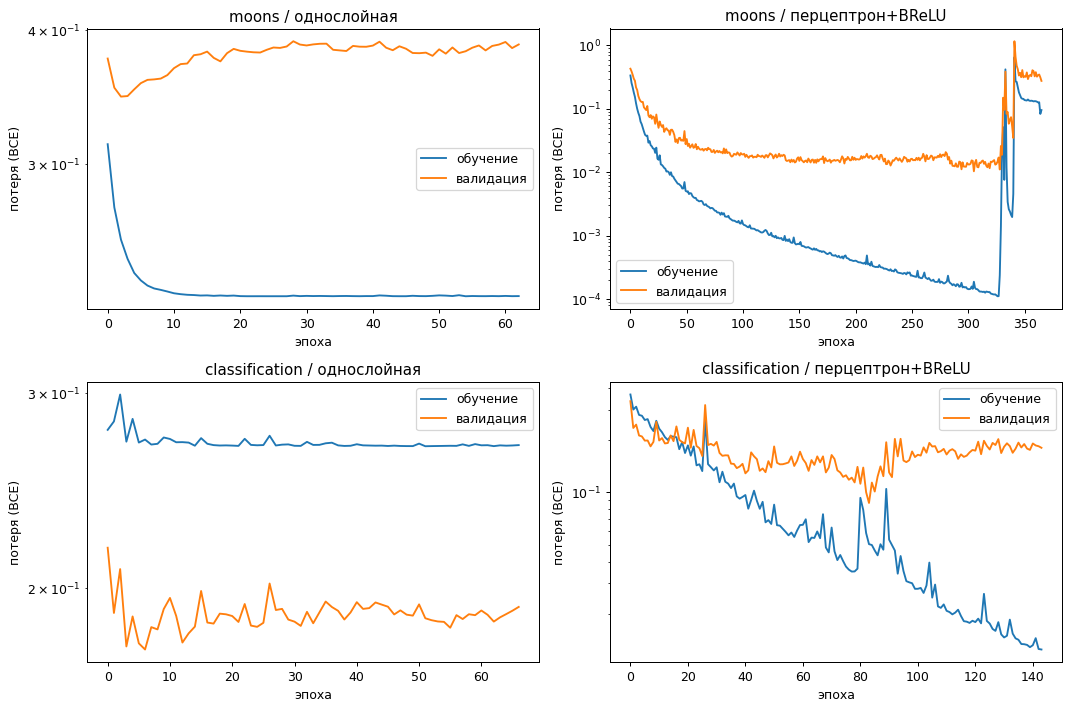

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
pairs = [
    ('moons / однослойная',          slp_m_h),
    ('moons / перцептрон+BReLU',     mlp_m_h),
    ('classification / однослойная', slp_c_h),
    ('classification / перцептрон+BReLU', mlp_c_h),
]
for ax, (title, h) in zip(axes.ravel(), pairs):
    ax.plot(h.train_loss, label='обучение')
    ax.plot(h.val_loss,   label='валидация')
    ax.set_title(title); ax.set_xlabel('эпоха'); ax.set_ylabel('потеря (BCE)')
    ax.set_yscale('log'); ax.legend()
plt.tight_layout(); plt.savefig('figures/05_final_curves.png', dpi=120); plt.show()


## 10. Выводы

- На `moons` нелинейная разделяющая поверхность принципиально нужна: однослойная (логистическая) модель упирается в потолок около 0.86–0.90 по доле верных ответов, а перцептрон с BReLU(1) и восемью нейронами в скрытом слое уверенно держит 0.97–1.00 на тестовой выборке.
- На `make_classification` (`n_informative = 2` из 5, по два кластера на класс) перцептрон не выиграл у однослойной модели: при `n_train = 120` и пяти признаках сетка с 16 скрытыми нейронами склонна переобучаться, а линейная модель остаётся устойчивой.
- Среди оптимизаторов на этих данных стабильно лидируют **Adam** (`momentum = classic + adaptive = rmsprop`) и **RMSProp**. Чистый SGD достигает сопоставимой финальной потери, но медленнее и сильнее зависит от выбора шага.
- Размер мини-выборки 16–32 даёт лучший компромисс между скоростью и устойчивостью. Меньшие пакеты — слишком шумные, полный батч сходится плавно, но застревает в плато.
- Ранняя остановка по валидационной потере заметно улучшает обобщающую способность на этих небольших данных.

Подробное обсуждение метрик и интерпретация результатов — в [`report.md`](./report.md).
